# A³ – Algorithm selection, Adapting features, Adjusting hyperparameters

## Ziel
Die A³-Phase ist die iterative Phase der Modellentwicklung und -optimierung. Hier werden Algorithmen evaluiert, Features adaptiert und Hyperparameter justiert, um für die Darmstadt-Verkehrsprognose die bestmögliche Modellleistung zu erreichen.


## A-Check: Modellwahl, Feature-Adaption, Hyperparameter

- **Algorithm selection**
  Es handelt sich um eine **Regression**, da `y` ein kontinuierliches Verkehrsaufkommen auf Stundenebene beschreibt.
- **Adapting features**
  Die aus der U-Phase übernommenen Zeit-, Lag- und Rolling-Features werden konsistent für alle Modelle verwendet.
- **Adjusting hyperparameters**
  Mehrere Regressoren (Linear, Ridge, RandomForest, GradientBoosting) werden mit identischem Preprocessing und chronologischem Split trainiert. Die Baumverfahren erhalten bewusst kontrollierte Hyperparameter, um robuste Generalisierung statt Overfitting auf den Trainingszeitraum zu fördern.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_FILE = repo_root / "data" / "df_final.csv"
REPORT_DIR = repo_root / "reports"
FIG_DIR = REPORT_DIR / "figures"
MODEL_DIR = REPORT_DIR / "models"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"{DATA_FILE} fehlt. Bitte zuerst U-Phase ausführen.")

df = pd.read_csv(DATA_FILE)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df = df.dropna(subset=["ds", "y"]).sort_values("ds").reset_index(drop=True)

print(f"Datensatz geladen: {len(df):,} Zeilen")
print(df.head())


Datensatz geladen: 8,734 Zeilen
                   ds        y  hour  hour_sin  hour_cos  weekday  is_weekend  \
0 2025-01-02 00:00:00  31323.0     0  0.000000  1.000000        3           0   
1 2025-01-02 01:00:00  27139.0     1  0.258819  0.965926        3           0   
2 2025-01-02 02:00:00  30240.0     2  0.500000  0.866025        3           0   
3 2025-01-02 03:00:00  23630.0     3  0.707107  0.707107        3           0   
4 2025-01-02 04:00:00  28376.0     4  0.866025  0.500000        3           0   

   month  weather    lag_1   lag_24  rolling_mean_3h  rolling_mean_12h  
0      1  unknown  33465.0  34566.0     32532.333333      51925.333333  
1      1  unknown  31323.0  50979.0     30461.666667      51081.000000  
2      1  unknown  27139.0  45016.0     30642.333333      48649.333333  
3      1  unknown  30240.0  32939.0     29567.333333      45772.583333  
4      1  unknown  23630.0  23765.0     27003.000000      42297.750000  


In [2]:
feature_cols = [
    "hour", "hour_sin", "hour_cos", "weekday", "is_weekend", "month",
    "lag_1", "lag_24", "rolling_mean_3h", "rolling_mean_12h", "weather",
]

target_col = "y"
X = df[feature_cols].copy()
y = df[target_col].astype(float).copy()

num_features = [c for c in feature_cols if c != "weather"]
cat_features = ["weather"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_features,
        ),
    ]
)

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

ts_train = df["ds"].iloc[:split_idx]
ts_test = df["ds"].iloc[split_idx:]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train-Zeitraum: {ts_train.iloc[0]} bis {ts_train.iloc[-1]}")
print(f"Test-Zeitraum:  {ts_test.iloc[0]} bis {ts_test.iloc[-1]}")


Train: 6,987 | Test: 1,747
Train-Zeitraum: 2025-01-02 00:00:00 bis 2025-10-20 04:00:00
Test-Zeitraum:  2025-10-20 05:00:00 bis 2025-12-31 23:00:00


In [3]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        min_samples_split=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42,
    ),
}

results = []
predictions = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    predictions[name] = y_pred
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,RandomForest,4874.081156,6807.078468,0.959767
1,GradientBoosting,5230.593246,7054.387811,0.956790
2,Ridge,6418.976133,8509.398325,0.937127
3,LinearRegression,6420.745781,8509.886952,0.937120


In [4]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]

pred_df = pd.DataFrame({"ds": ts_test.reset_index(drop=True), "y_true": y_test.reset_index(drop=True)})
for model_name, y_pred in predictions.items():
    pred_df[f"pred_{model_name}"] = y_pred

results_path = REPORT_DIR / "model_results.csv"
preds_path = REPORT_DIR / "predictions_test.csv"
summary_path = REPORT_DIR / "model_summary.json"
model_path = MODEL_DIR / f"best_model_{best_model_name}.pkl"

results_df.to_csv(results_path, index=False, encoding="utf-8")
pred_df.to_csv(preds_path, index=False, encoding="utf-8")

summary_payload = {
    "best_model": best_model_name,
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "dataset_rows": int(len(df)),
    "metrics": results_df.to_dict(orient="records"),
}
summary_path.write_text(json.dumps(summary_payload, indent=2, ensure_ascii=False), encoding="utf-8")

import pickle
with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)

print(f"Bestes Modell: {best_model_name}")
print(f"Ergebnisse: {results_path}")
print(f"Vorhersagen: {preds_path}")
print(f"Modellartefakt: {model_path}")


Bestes Modell: RandomForest
Ergebnisse: Z:\Traffic-Prediction-Optimization\reports\model_results.csv
Vorhersagen: Z:\Traffic-Prediction-Optimization\reports\predictions_test.csv
Modellartefakt: Z:\Traffic-Prediction-Optimization\reports\models\best_model_RandomForest.pkl


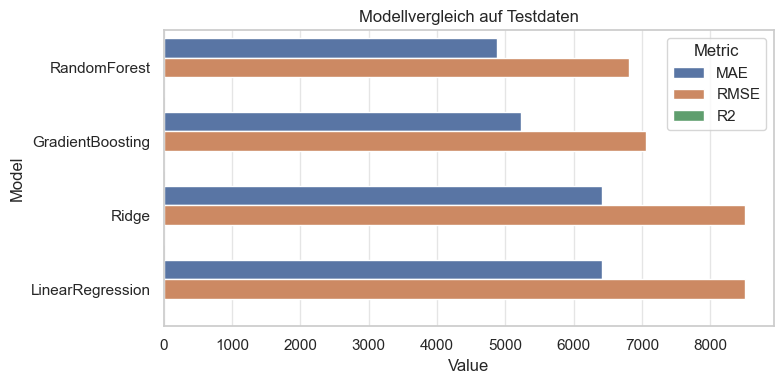

In [5]:
plt.figure(figsize=(8, 4))
plot_df = results_df.melt(id_vars="Model", value_vars=["MAE", "RMSE", "R2"], var_name="Metric", value_name="Value")
sns.barplot(data=plot_df, x="Value", y="Model", hue="Metric", orient="h")
plt.title("Modellvergleich auf Testdaten")
plt.tight_layout()
plt.savefig(FIG_DIR / "a_phase_model_comparison.png", dpi=160)
plt.show()


### Modellvergleich auf Testdaten

Dieses Balkendiagramm vergleicht alle trainierten Modelle auf demselben chronologischen Testzeitraum. Dargestellt werden die drei Kennzahlen **MAE**, **RMSE** und **R²**.

- **MAE** zeigt die durchschnittliche absolute Abweichung zwischen Prognose und Ist-Wert. Kleinere Werte sind besser.
- **RMSE** gewichtet größere Fehler stärker als MAE und ist deshalb besonders wichtig, wenn starke Fehlprognosen in Spitzenzeiten vermieden werden sollen. Kleinere Werte sind besser.
- **R²** beschreibt, wie gut das Modell die Schwankungen im Verkehrsaufkommen erklärt. Größere Werte sind besser.

Für die Auswahl des besten Modells ist vor allem der **RMSE** relevant, weil im Verkehrsmanagement starke Fehlprognosen operativ kritischer sind als kleine durchschnittliche Abweichungen. Das Modell mit der besten Gesamtbalance wird anschließend in der nächsten Grafik detaillierter betrachtet.


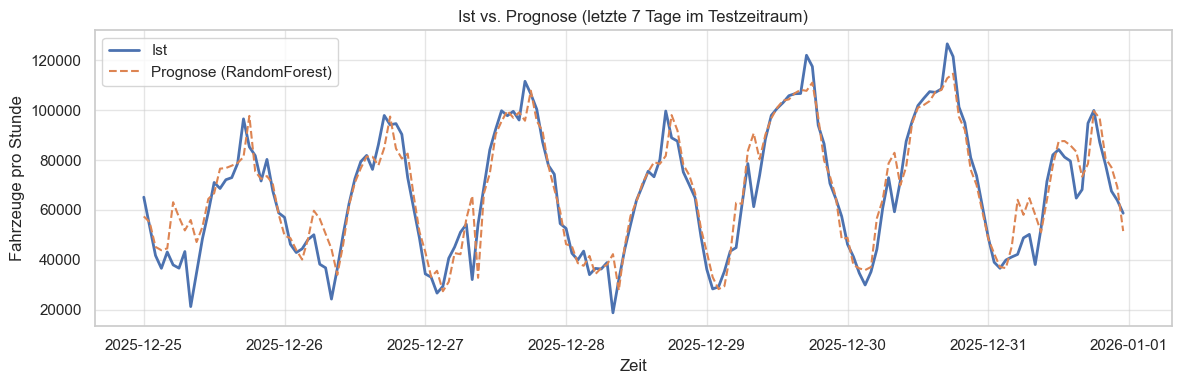

In [6]:
best_col = f"pred_{best_model_name}"
view_n = min(24 * 7, len(pred_df))

plt.figure(figsize=(12, 4))
plt.plot(pred_df["ds"].iloc[-view_n:], pred_df["y_true"].iloc[-view_n:], label="Ist", linewidth=2)
plt.plot(pred_df["ds"].iloc[-view_n:], pred_df[best_col].iloc[-view_n:], label=f"Prognose ({best_model_name})", linestyle="--")
plt.title("Ist vs. Prognose (letzte 7 Tage im Testzeitraum)")
plt.xlabel("Zeit")
plt.ylabel("Fahrzeuge pro Stunde")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "a_phase_best_model_timeseries.png", dpi=160)
plt.show()


### Ist vs. Prognose des besten Modells

Dieses Liniendiagramm zeigt für die letzten sieben Tage des Testzeitraums den Vergleich zwischen den **tatsächlich gemessenen Werten** und der **Vorhersage des besten Modells**.

- Die durchgezogene Linie (**Ist**) steht für das reale Verkehrsaufkommen.
- Die gestrichelte Linie (**Prognose**) zeigt, wie gut das ausgewählte Modell den tatsächlichen Verlauf nachbildet.

Wichtig ist hier nicht nur die durchschnittliche Nähe der Linien, sondern auch, ob das Modell typische Verkehrsmuster korrekt trifft: Morgen- und Abendspitzen, ruhigere Nachtphasen sowie kurzfristige Ausschläge.

Je enger beide Linien zusammenlaufen, desto belastbarer ist das Modell für die operative Nutzung. Sichtbare Abweichungen markieren Zeitfenster, in denen das Modell noch Unsicherheit hat oder externe Einflüsse nicht vollständig abbildet.


## Ergebnis der A³-Phase
- Vier Modellfamilien wurden unter identischem Zeitreihen-Setup verglichen.
- Features aus der U-Phase wurden erfolgreich in die Modellpipeline überführt.
- Das beste Modell wurde anhand des kleinsten RMSE ausgewählt.
- Ergebnisse, Testvorhersagen und Modellartefakt wurden für C- und K-Phase exportiert.
